# 5 ラベルなしデータでの事前学習

**重み** (weight) : 学習プロセスで調整する訓練可能なパラメータのこと。 

- `layer.weight` : 層の重みにアクセス
- `model.parameters()` : モデルの訓練可能なすべてのパラメータ

## 5.1 生成テキストモデルを評価する

まずは評価する方法を設定する。

### 5.1.1 GPT を使ってテキストを生成する。

In [1]:
import torch
import torch.nn as nn

In [2]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim, eps=1e-5):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False) # 不変ではなく有偏分散。n がデカいのでその差がほぼ無視でき、正規化層との互換性を保つため。
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

class GELU(nn.Module):
    def __init__(self):
        super().__init__()
        
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))))
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn. Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]), # 埋め込み次元を 4 倍に拡張
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]) # 元の埋め込み次元に戻す
        )
    def forward(self, x):
        return self.layers(x)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), "d_out must be divisible by num_heads"
    
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # 出力次数をhead で分割    

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        
        self.out_proj = nn.Linear(d_out, d_out) # Linear 層を使ってヘッドの出力を組み合わせる
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )
        
    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        
        keys = keys.transpose(1, 2) # (b, num_heads, num_tokens, head_dim)
        queries = queries.transpose(1, 2) # (b, num_heads, num_tokens, head_dim)
        values = values.transpose(1, 2) # (b, num_heads, num_tokens, head_dim)
        
        attn_scores = queries @ keys.transpose(2, 3) # 各ヘッドドット積を計算
        
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens] # マスクをトークン数で切り捨て
        attn_scores.masked_fill_(mask_bool, -torch.inf) # Attention スコアを埋めるためにマスクを使う
        
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        attn_weights = self.dropout(attn_weights) # ドロップアウトを適用
        
        context_vec = (attn_weights @ values).transpose(1, 2) # (b, num_heads, num_tokens, head_dim)
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out) # self.out に基づいてヘッドを結合
        
        context_vec = self.out_proj(context_vec) # 線形射像を追加 (これなにやってんの？)
        
        return context_vec
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in = cfg["emb_dim"],
            d_out = cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])
    
    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )
    
    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device) # 入力データがGPUにあるかCPUのどちらにあるかに応じて、モデルをどちらかのデバイスで訓練できる。
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits # 次に来るトークンの、正規化されていない確率で返す

訓練時間を短縮するためにコンテキストの長さ `context_length` 256 トークンに減らす。これにより、ノート PC でも訓練できるようになる。

In [3]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

テキスト生成プロセスを実装

In [4]:
import tiktoken
def generate_text_simple(model, idx,
                         max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:] # サポートされているコンテキストサイズを超える場合は現在のコンテキストを切り詰める。最後のトークンが使われる。
        with torch.no_grad():
            logits = model(idx_cond)
    
        logits = logits[:, -1, :] # 最後のタイムステップにのみ着目する。(batch, n_token, vocab_size) -> (batch, vcab_size)

        probas = torch.softmax(logits, dim=-1) # (batch, vocab_size) 今のことろ、logits のときと大小の順序が変わらないので以下の argmax に影響しない冗長な実装
        
        idx_next = torch.argmax(probas, dim=-1, keepdim=True) # 最も確率の高いトークンを返す。(batch, 1)
        
        idx = torch.cat((idx, idx_next), dim=-1) # 実行中のシーケンスに追加。
    
    return idx

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # バッチ次元を追加
    
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

In [5]:
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(start_context, tokenizer),
    max_new_tokens = 10,
    context_size = GPT_CONFIG_124M["context_length"]
)
print("Output text: \n", token_ids_to_text(token_ids, tokenizer))

Output text: 
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


4 章最後と同様にでたらめな文字列が返ってきた。

### 5.1.2.　テキスト生成の損失を計算する

次のようなサンプルで学習したい。

In [6]:
inputs = torch.tensor([[26833, 3626, 6100], # ["every effort moves",
                       [40, 1107, 11311]]) #  "I really like"]

targets = torch.tensor([[3626, 6100, 345], # [" effort moves you",
                        [1107, 588, 11311]]) # " really like chocolate"]

入力 `inputs` に対して現在のモデルの出力結果を確認する

In [7]:
with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim = -1) # logits を確率に変換
print(probas.shape)

torch.Size([2, 3, 50257])


In [8]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True) # 最も確率の高いトークンを選択
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[ 7269],
         [16031],
         [21177]],

        [[49906],
         [29669],
         [35663]]])


In [9]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1:"
      f" {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")
print()
print(f"Targets batch 1: {token_ids_to_text(targets[1], tokenizer)}")
print(f"Outputs batch 1:"
      f" {token_ids_to_text(token_ids[1].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  schedule saves Admir

Targets batch 1:  really like chocolate
Outputs batch 1:  pressuring empowered Blackhawks


`target` トークンに対応するソフトマックス確率スコアを確認する。

In [10]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]] # [バッチ、[1番目の確率分布, 2.., 3..], [目標のトークン]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([1.3183e-04, 3.1035e-05, 1.0419e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 6.0807e-06])


この確率が高いほどいいモデルといえる。

これら二つから損失関数を計算してみる。

- 対数確率に変換
- 確率大 --> 0, 確率小 --> $-\infty$

In [11]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2), dim=0)) # log 確率を計算
print(log_probas)

tensor([ -8.9340, -10.3804, -11.4719, -11.4798,  -9.7764, -12.0104])


- 平均対数確率

In [12]:
avg_log_probas = torch.mean(log_probas) # 平均対数確率
print(avg_log_probas)

tensor(-10.6755)


**交差エントロピー誤差** (cross entropy loss): 2 つの確率分布の差を定量的に計測する指標。

In [13]:
neg_avg_log_probas = avg_log_probas * -1 # 対数確率を負にする
print(neg_avg_log_probas)

tensor(10.6755)


この一連の操作は `cross_entropy()` で実装できるのでそれを試す。まずはデータ整形。

In [14]:
print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


In [15]:
logits_flat = logits.flatten(0, 1) # バッチとトークンをフラット化
targets_flat = targets.flatten()
print("Flatted logits:", logits_flat.shape)
print("Flatted targets:", targets_flat.shape)

Flatted logits: torch.Size([6, 50257])
Flatted targets: torch.Size([6])


In [16]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.6755)


**パープレキシティ** : モデル性能の評価指標の一種。学習後の確率分布の一致度を計算する。
- `peplexity = torch.exp(loss)`
- 各ステップでモデルが不確かとなる実質的な語彙サイズを示す。

In [17]:
peplexity = torch.exp(loss)
print("Perplexity:", peplexity)

Perplexity: tensor(43281.3047)


### 5.1.3 訓練データセットと検証データセットで損失を計算

"The Verdict" で訓練、検証してみる。  
**Project Gutenberg** : パブリックドメインの書籍が 6 万冊以上ある。

※ 事前学習コストは高い。Llama 2 モデルの訓練では、パラメータ数 70 億で 2 兆個のトークンを処理しており、A100GPU で 184320 GPU 時間かかった。AWS の A100GPU 8 基のサーバー(30 ドル/時間) で同じことをしようとすると、$ 690,000 =(184320 / 8) \times 30$ ドル 以上かかる。

In [18]:
file_path = "./src/the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

total_charaters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_charaters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


これくらいであればノートPCでも訓練実行できる範囲。

トークン化 --> データセット単位を最大長 6 のチャンクに分割 --> バッチ化（データセットをシャッフルして 2 個でひとまとまりにする）  
※ チャンクのサイズは実際のデータローダーでは `context_length=256` に揃える。可変長で訓練するのも効果的である。

In [19]:
train_ratio = 0.9 # データセットの 90% を訓練データ、10% を検証データに分割
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [20]:
import torch
from torch.utils.data import Dataset, DataLoader
class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []
        token_ids = tokenizer.encode(txt) # テキスト全体のトークン化
        
        # The Verdict を max_length の長さに分割する
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i+max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))
    
    def __len__(self): # データセットの行数を考える
        return len(self.input_ids)
    
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]
def create_dataloader_v1(txt, 
                         batch_size=4,# 一つのテンソルのサイズ
                         max_length=256,
                         stride=128, # 入力(出力)token内の次の インデックスまでのジャンプ
                         shuffle=True,
                         drop_last=True, 
                         num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    
    dataloader = DataLoader(
        dataset, 
        batch_size = batch_size, 
        shuffle=shuffle,
        drop_last = drop_last,
        num_workers=num_workers
    )
    
    return dataloader

In [21]:
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [22]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [23]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )
    return loss


In [24]:
def calc_loss_loader(data_loader, model, defvice, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, defvice
                )
            total_loss += loss.item()
        else:
            break
        
    return total_loss / num_batches

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Train loss:", train_loss)
print("Validation loss:", val_loss)

Train loss: 10.987583584255642
Validation loss: 10.981104850769043


## 5.2 LLM を訓練する

In [26]:
def train_model_simple(model, train_loader, val_loader, optimizer, device,
                       num_epochs, eval_freq, eval_iter, start_context,
                       tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1
    
    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            
            global_step += 1
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}) "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}")
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )
    return train_losses, val_losses, track_tokens_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
        model.train()
    return train_loss, val_loss

def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model,
            idx=encoded,
            max_new_tokens=50,
            context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

In [27]:
torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(),
                              lr=0.0004,
                              weight_decay=0.1
                              )

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000) Train loss 9.817, Val loss 9.928
Ep 1 (Step 000005) Train loss 8.067, Val loss 8.334
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010) Train loss 6.624, Val loss 7.051
Ep 2 (Step 000015) Train loss 6.049, Val loss 6.603
Every effort moves you, the,, and,,,,,,, and,.                                   
Ep 3 (Step 000020) Train loss 5.549, Val loss 6.501
Ep 3 (Step 000025) Train loss 5.413, Val loss 6.366
Every effort moves you, and to the of the of the of the, and I had. Gis, and, and, and, and, and, and I had, and, and, and, and, and, and, and, and, and,
Ep 4 (Step 000030) Train loss 4.912, Val loss 6.283
Ep 4 (Step 000035) Train loss 4.665, Val loss 6.310
Every effort moves you of the picture.                        "I"IHe the picture"I"I           
Ep 5 (Step 000040) Train loss 3.966, Val loss 6.152
Every effort moves you know the                          "Oh, and his pictures a, and he said.          
Ep 6 (Step 000045) Tra

なんとなく文法が守られた文章が生成された。

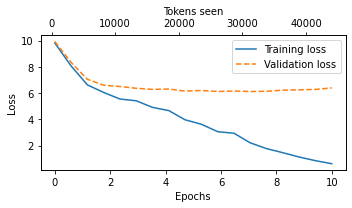

In [28]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="--", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epoch_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epoch_tensor, tokens_seen, train_losses, val_losses)

エポック 2 以降ではモデルに過剰適合しているといえる。実際、"quite insensible to the irony" などは丸暗記しているようだ。  

## 5.3 ランダム性をコントロールするデコーディング戦略

In [29]:
model.to("cpu")
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

さっきの訓練結果を確認する

In [30]:
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text: \n", token_ids_to_text(token_ids, tokenizer))

Output text: 
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




このモデルで何回出力をためしても同じ結果が返ってくるので、確率を使って出力に多様化させたい。


### 5.3.1 温度スケーリング
**温度スケーリング** (temperature scaling) : トークン生成を確率的な選択プロセスで行うテクニック。

In [31]:
vocab = {
    "closer":0,
    "every":1,
    "effort":2,
    "forward":3,
    "inches":4,
    "moves":5,
    "pizza":6,
    "toward":7,
    "you":8
}

inverse_vocab = {v: k for k, v in vocab.items()}

もう一度、貪欲的な実装の流れを確認

In [32]:
next_token_logits = torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79])
probas = torch.softmax(next_token_logits, dim=0)

next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

forward


In [33]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item() # 確率に基づいてトークンを選択
print(inverse_vocab[next_token_id]) # テキストでは "forward" が選択される

toward


In [34]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item() for _ in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

71 x closer
2 x every
0 x effort
544 x forward
2 x inches
1 x moves
0 x pizza
376 x toward
4 x you


In [35]:
def softmax_with_temperature(logits, temperature=1.0):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

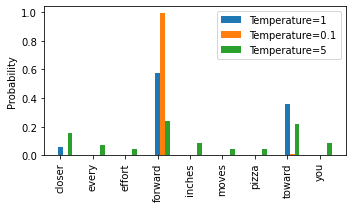

In [36]:
temperature = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T)
                 for T in temperature]
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperature):
    rects = ax.bar(x+i*bar_width, scaled_probas[i], width=bar_width, label=f"Temperature={T}")
ax.set_ylabel("Probability")
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

In [37]:
for probas in scaled_probas:
    print_sampled_tokens(probas)
    print()

71 x closer
2 x every
0 x effort
544 x forward
2 x inches
1 x moves
0 x pizza
376 x toward
4 x you

0 x closer
0 x every
0 x effort
992 x forward
0 x inches
0 x moves
0 x pizza
8 x toward

153 x closer
68 x every
55 x effort
223 x forward
102 x inches
50 x moves
43 x pizza
218 x toward
88 x you



全体から選択してしまうと意味のないものまで出てくることになる。

**top-k サンプリング** : ロジッツ上位 k 個を決めちしてその中から確率的に選ぶ

In [38]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, k=top_k) # 上位 k 個のトークンを選択
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [39]:
next_token_logits < top_logits[-1]

tensor([False,  True,  True, False,  True,  True,  True, False,  True])

In [40]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")),
    other= next_token_logits
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [41]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


### 5.3.3 テキスト生成関数を修正する

In [42]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0,
             top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float("-inf"), device=logits.device),
                logits
            )
        
        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        
        if idx_next == eos_id:
            break
        
        idx = torch.cat((idx, idx_next), dim=1) # idx_next を idx に追加
    return idx

In [43]:
torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],

    top_k=25,
    temperature=3
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you know Jack G to a hint a little too again on my dear fellow enough


## 5.4 PyTorch での重みの保存と読み込み

In [44]:
torch.save(model.state_dict(), "./src/model.pth") # モデルの重みを保存

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("./src/model.pth", map_location=device))
model.eval()

/tmp/ipykernel_465272/4127469806.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("./src/model.pth", map_location=device))


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

AdamW は適応型オプティマイザで、モデルの重みに追加のパラメータを格納する。したがって、オプティマイザの `state_dict()` も保存したい。

In [45]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict()
    },
    "./src/model_and_optimizer.pth"
)

復元する。

In [46]:
checkpoint = torch.load("./src/model_and_optimizer.pth", map_location=device)
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(),
                              lr=5e-4,
                              weight_decay=0.1
                              )
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

/tmp/ipykernel_465272/182778431.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("./src/model_and_optimizer.pth", map_location=device)


## 5.5 OpenAI から事前学習済の重みを読み込む

書籍の GitHub から必要なデータだけ持ってくることにする。

In [47]:
from sys import path
path.append("./src")

import urllib.request
url = ("https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch05/"
"01_main-chapter-code/gpt_download.py")
filename = "./src/" + url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('./src/gpt_download.py', <http.client.HTTPMessage at 0x71812d253ee0>)

In [48]:
from gpt_download import download_and_load_gpt2

settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="./src/gpt2"
)

2025-09-03 09:58:11.701741: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-03 09:58:11.717642: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756861091.731501  465272 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756861091.735601  465272 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756861091.748271  465272 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

File already exists and is up-to-date: ./src/gpt2/124M/checkpoint
File already exists and is up-to-date: ./src/gpt2/124M/encoder.json
File already exists and is up-to-date: ./src/gpt2/124M/hparams.json
File already exists and is up-to-date: ./src/gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: ./src/gpt2/124M/model.ckpt.index
File already exists and is up-to-date: ./src/gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: ./src/gpt2/124M/vocab.bpe


In [49]:
print("Settings:", settings)
print("parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [50]:
print(params["wte"])
print("")

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]



In [51]:
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads":12}, 
    "gpt2-medium (335M)": {"emb_dim": 1024, "n_layers": 24, "n_heads":16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads":20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads":25} 
}

In [52]:
model_name ="gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])

gpt2 オリジナルのコンテキスト長さは 1024 トークン

In [53]:
NEW_CONFIG.update({"context_length": 1024})

バイアスベクトルはモデル性能向上に寄与しないのでほとんど使われなくなってきているが、事前学習済みの重みを使っているので、一貫性を保つためにバイアスベクトルを有効にしておく。

In [54]:
NEW_CONFIG.update({"qkv_bias":True})

In [55]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

箱ができたので GPTModel のランダマイズされた重みを学習済みデータで置き換える。

`assign(left, right)` : `left` と `right` のテンソルの形が同じなら pytorch のパラメータテンソルとして `right` を返す

In [56]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(
            f"Shape mismatch. Left: {left.shape}, "
            f"!= {right.shape}"
        )
    else:
        return torch.nn.Parameter(torch.tensor(right))

GPT の訓練済みパラメータを自作クラスの gpt に代用してみる。

In [57]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params["wpe"])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params["wte"])
    
    for b in range(len(params["blocks"])):
        # Attention の Q, K, W の重み
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T
        )
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T
        )

        # Attention の Q, K, W のバイアス
        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b
        )
        
        # Attention のヘッド結合時の線形写像
        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        # Attention のヘッド結合時のバイアス
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])
        
        # FeedForward の最初の線形写像
        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        # FeedForward の最初のバイアス
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])

        # FeedForward の最後の線形写像
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        # FeedForward の最後のバイアス
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])
        
        # transformer 内 LayerNorm 1 のパラメータを設定
        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
         
        # transformer 内 LayerNorm 2 のパラメータを設定
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    # 最後の LayerNorm のパラメータを設定
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.scale, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

In [58]:
load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [98]:
torch.manual_seed(123)
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("I think this meeting is", tokenizer).to(device),
    max_new_tokens=15,
    context_size=NEW_CONFIG["context_length"],
    top_k=3,
    temperature=1 # 1温度を上げると比較的でたらめになった。
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 I think this meeting is important because it gives us the opportunity to talk about the future of the game
